# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 80°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 316
Average Fx in the averaging interval [800:1116]: 6.430412761873334
Average Fz in the averaging interval [800:1116]: 0.5045155714332806
Maximum Fz in the plotting interval [800:1130]: 1.1029459635416667 at timestep 1093
Time step where Fx drops below 1: 1116


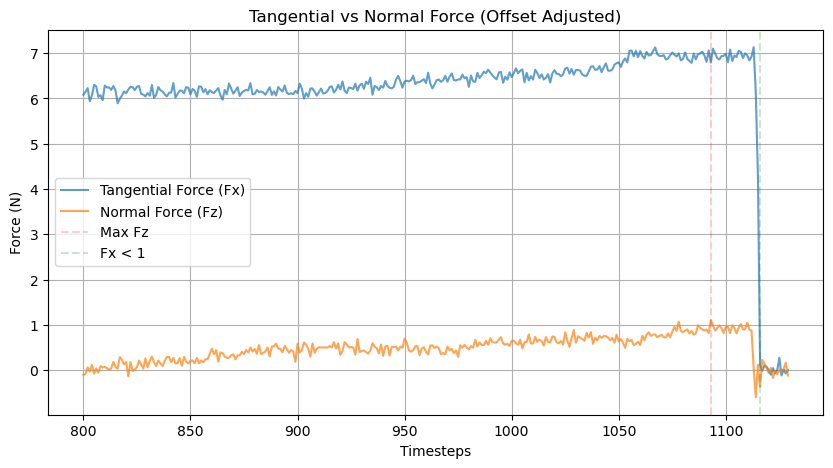

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280938.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=800, cut_2=1130, avg_end=1116, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 295
Average Fx in the averaging interval [790:1085]: 6.753250617496038
Average Fz in the averaging interval [790:1085]: 0.810851774916137
Maximum Fz in the plotting interval [790:1100]: 1.5938395182291667 at timestep 1057
Time step where Fx drops below 1: 1085


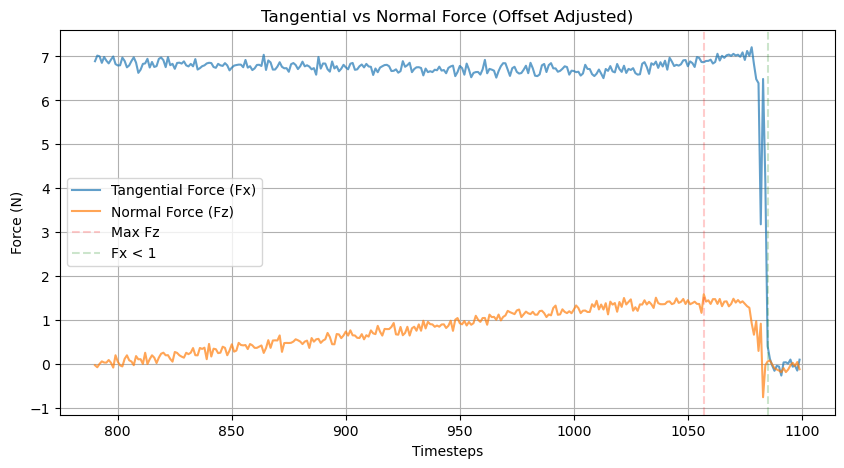

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280939.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=790, cut_2=1100, avg_end=1085, offset_position='beginning', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 499
Average Fx in the averaging interval [745:1244]: 5.638032746362781
Average Fz in the averaging interval [745:1244]: 0.8219821723525175
Maximum Fz in the plotting interval [745:None]: 1.92928466796875 at timestep 1229
Time step where Fx drops below 1: 1244


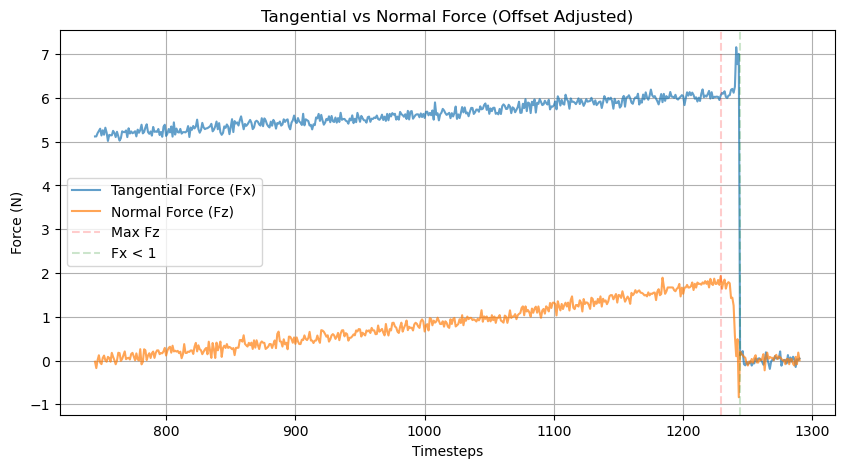

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280940.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=745, cut_2=None, avg_end=1244, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 815
Average Fx in the averaging interval [1405:2220]: 4.666084494034937
Average Fz in the averaging interval [1405:2220]: 0.9832815595443507
Maximum Fz in the plotting interval [1405:None]: 2.146439615885417 at timestep 2207
Time step where Fx drops below 1: 2220


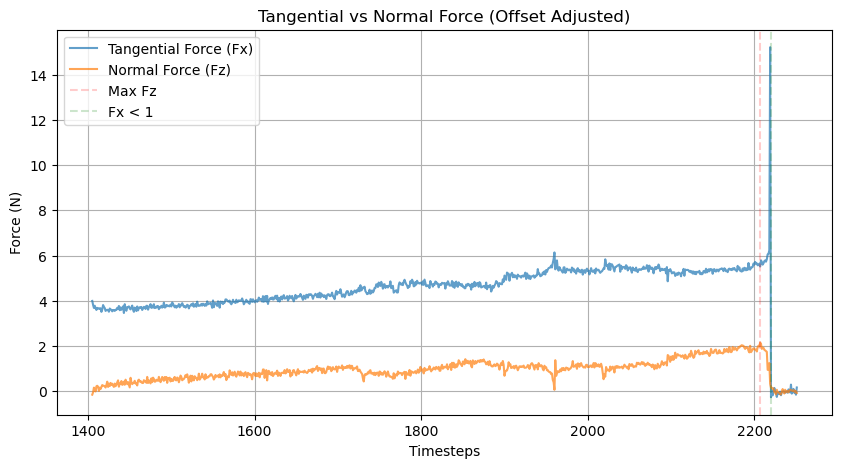

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280942.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=1405, cut_2=None, avg_end=2220, offset_position='end', offset_length=15)

<font size="6">Test 5: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.728410597126262
Average Fz in the averaging interval [None:None]: -1.734892834639752
Maximum Fz in the plotting interval [None:None]: 0.20127766927083335 at timestep 836
Time step where Fx drops below 1: 0


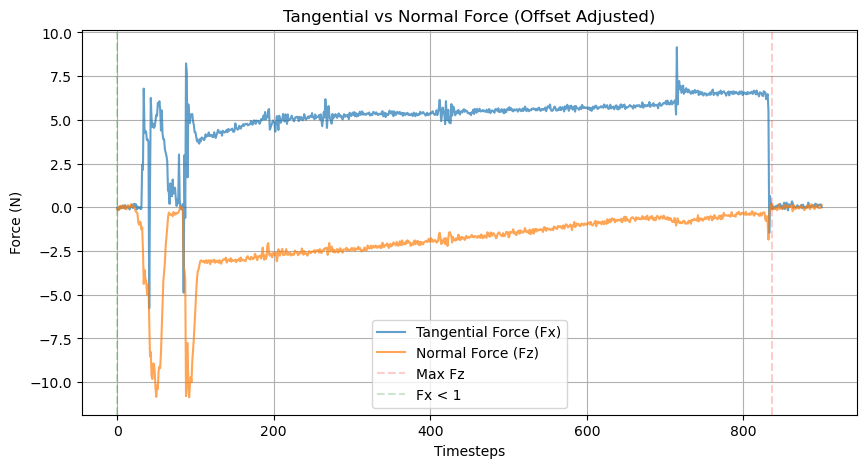

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280956.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 460
Average Fx in the averaging interval [1039:1499]: 5.184238372332808
Average Fz in the averaging interval [1039:1499]: 0.952726856176404
Maximum Fz in the plotting interval [1039:None]: 2.1043416341145833 at timestep 1486
Time step where Fx drops below 1: 1499


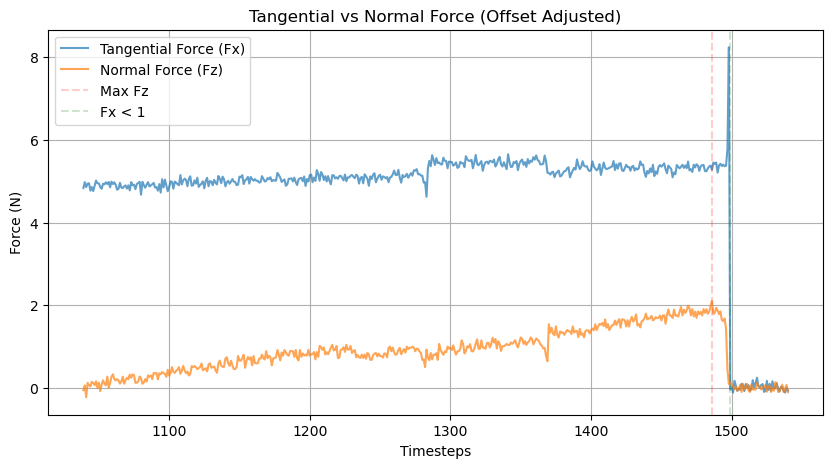

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405280959.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1039, cut_2=None, avg_end=1499, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 421
Average Fx in the averaging interval [830:1251]: 6.8681530664388095
Average Fz in the averaging interval [830:1251]: 0.2959969539446011
Maximum Fz in the plotting interval [830:None]: 1.3649007161458333 at timestep 1237
Time step where Fx drops below 1: 1251


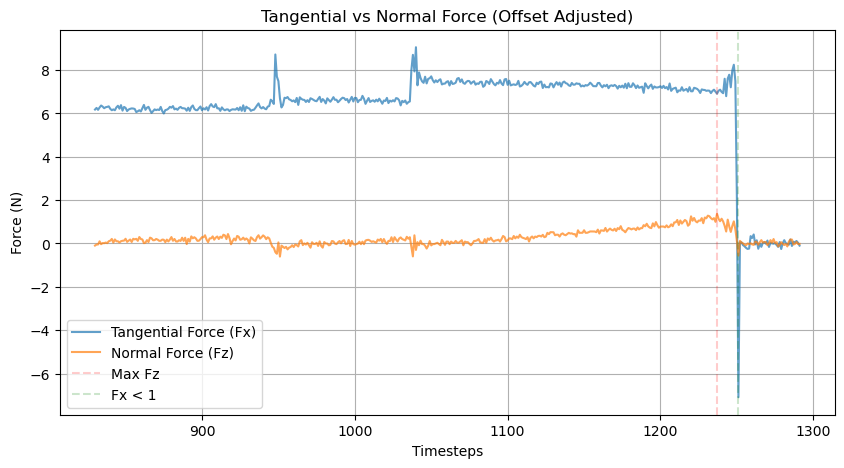

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405281000.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=830, cut_2=None, avg_end=1251, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 339
Average Fx in the averaging interval [1083:1422]: 7.831207762917938
Average Fz in the averaging interval [1083:1422]: 0.6570546198031896
Maximum Fz in the plotting interval [1083:None]: 1.3190104166666665 at timestep 1369
Time step where Fx drops below 1: 1422


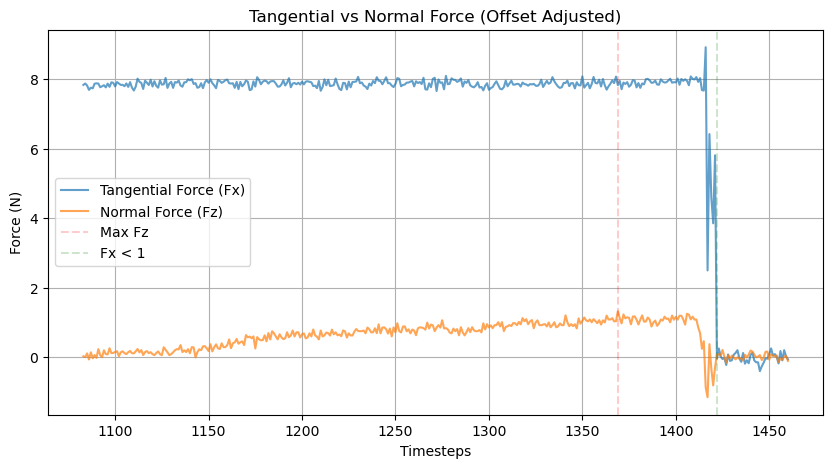

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405281001.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=1083, cut_2=None, avg_end=1422, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 424
Average Fx in the averaging interval [595:1019]: 7.242125296442763
Average Fz in the averaging interval [595:1019]: 0.4285988957627015
Maximum Fz in the plotting interval [595:None]: 0.9894816080729166 at timestep 1002
Time step where Fx drops below 1: 1019


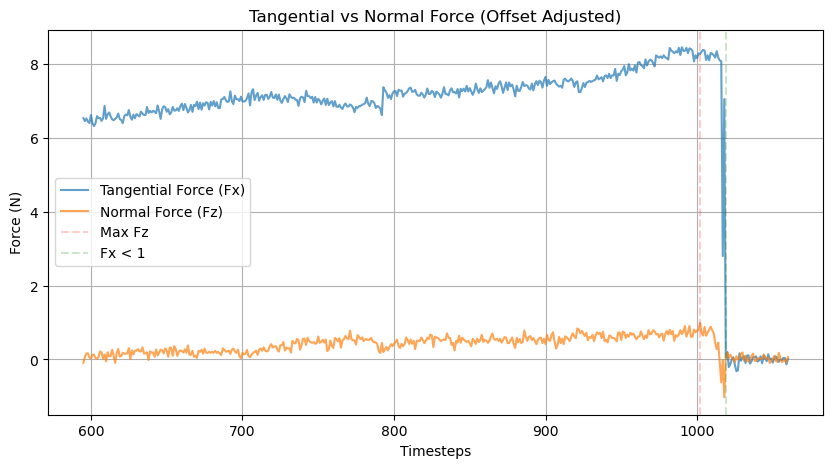

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405281002.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=595, cut_2=None, avg_end=1019, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 857
Average Fx in the averaging interval [190:1047]: 6.306435411609781
Average Fz in the averaging interval [190:1047]: 0.6482153567206946
Maximum Fz in the plotting interval [190:None]: 1.7763020833333334 at timestep 1031
Time step where Fx drops below 0.2: 1047


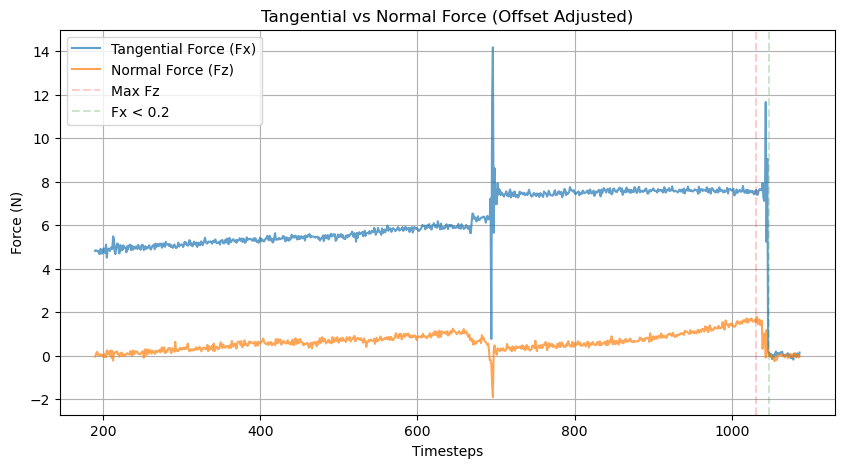

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_80_5N//log_202405281003.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=190, cut_2=None, avg_end=1047, offset_position='end', offset_length=15, fx_threshold=0.2)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//80//MatrixBrekzie_80_stats.csv", index=False)

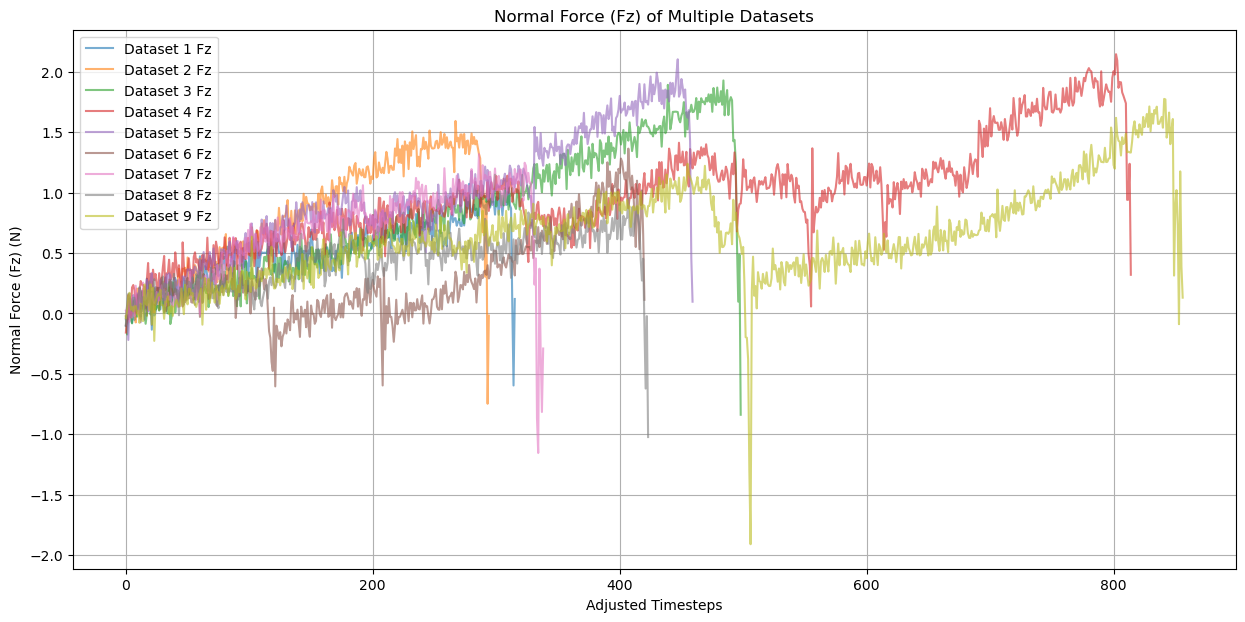

Average of maximum Fz forces: 1.591838469328704
Standard deviation of maximum Fz forces: 0.40082252270913454
Average of average Fz forces: 0.6781359734059862
Standard deviation of average Fz forces: 0.22276093030411365
Average of average Fx forces: 6.324437836612131
Standard deviation of average Fx forces: 0.9501409184451997


In [18]:
tests = [test_1, test_2, test_3, test_4, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//80//MatrixBrekzie_80"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)